Dataset cargado: 303 muestras de entrenamiento, 203 de validación.

--- PARTE 1: MEJOR CONFIGURACIÓN ---
Mejor K: 2
Mejor Métrica: Euclidiana
RMSE de Validación: 3.8593

--- PARTE 1b ---
Predicción MEDV para el caso dado: $19,550.00

--- PARTE 2: BENCHMARKING DE ALGORITMOS ---


C:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Tiempo de respuesta (brute): 0.005712 segundos
Tiempo de respuesta (kd_tree): 0.004154 segundos
Tiempo de respuesta (ball_tree): 0.004406 segundos

--- PARTE 2d: EXPERIMENTO LEAF SIZE (KD-Tree) ---
Leaf Size:    2 | Tiempo: 0.0112105s | Primer Pred: 27.35
Leaf Size:   30 | Tiempo: 0.0038582s | Primer Pred: 27.35
Leaf Size:  100 | Tiempo: 0.0039778s | Primer Pred: 27.35
Leaf Size:  500 | Tiempo: 0.0049887s | Primer Pred: 27.35

--- PARTE 3: ANÁLISIS ---
RMSE Entrenamiento: 2.5349
RMSE Validación:    3.8593


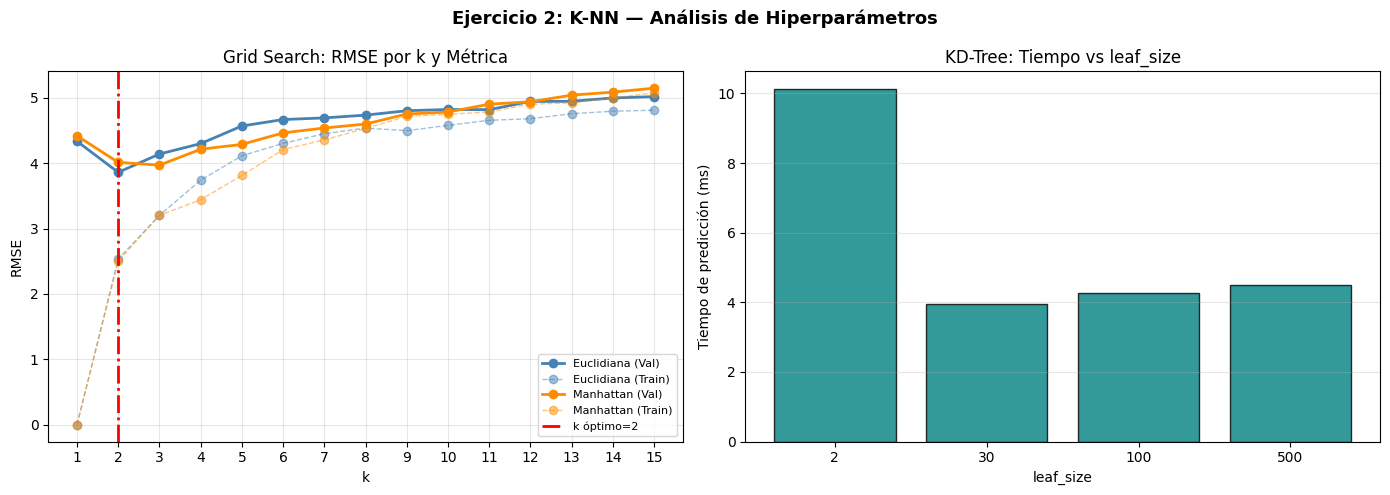

In [24]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

df = pd.read_csv("BostonHousing.csv")
X = df.drop(columns=["medv"]).values
y = df["medv"].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.40, random_state=42)
print(f"Dataset cargado: {len(X_train)} muestras de entrenamiento, {len(X_val)} de validación.")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

mejor_rmse, mejor_k, mejor_p, mejor_metrica = np.inf, None, None, None
for p, nombre in [(2, "Euclidiana"), (1, "Manhattan")]:
    for k in range(1, 16):
        modelo = KNeighborsRegressor(n_neighbors=k, p=p)
        modelo.fit(X_train_sc, y_train)
        rmse = np.sqrt(mean_squared_error(y_val, modelo.predict(X_val_sc)))
        if rmse < mejor_rmse:
            mejor_rmse, mejor_k, mejor_p, mejor_metrica = rmse, k, p, nombre

print(f"\n--- PARTE 1: MEJOR CONFIGURACIÓN ---")
print(f"Mejor K: {mejor_k}")
print(f"Mejor Métrica: {mejor_metrica}")
print(f"RMSE de Validación: {mejor_rmse:.4f}")

knn_opt = KNeighborsRegressor(n_neighbors=mejor_k, p=mejor_p)
knn_opt.fit(X_train_sc, y_train)

caso = pd.DataFrame([{"crim": 0.2, "zn": 0, "indus": 7, "chas": 0, "nox": 0.538,
                      "rm": 6, "age": 62, "dis": 4.7, "rad": 4, "tax": 307,
                      "ptratio": 21, "lstat": 10}])
caso_sc = scaler.transform(caso)
pred = knn_opt.predict(caso_sc)[0]
print(f"\n--- PARTE 1b ---")
print(f"Predicción MEDV para el caso dado: ${pred*1000:,.2f}")

print(f"\n--- PARTE 2: BENCHMARKING DE ALGORITMOS ---")
for alg in ["brute", "kd_tree", "ball_tree"]:
    m = KNeighborsRegressor(n_neighbors=mejor_k, p=mejor_p, algorithm=alg)
    m.fit(X_train_sc, y_train)
    t0 = time.time()
    for _ in range(50):
        m.predict(X_val_sc)
    t = (time.time() - t0) / 50
    print(f"Tiempo de respuesta ({alg}): {t:.6f} segundos")

print(f"\n--- PARTE 2d: EXPERIMENTO LEAF SIZE (KD-Tree) ---")
for ls in [2, 30, 100, 500]:
    m = KNeighborsRegressor(n_neighbors=mejor_k, p=mejor_p, algorithm="kd_tree", leaf_size=ls)
    m.fit(X_train_sc, y_train)
    t0 = time.time()
    for _ in range(50):
        preds = m.predict(X_val_sc)
    t = (time.time() - t0) / 50
    print(f"Leaf Size: {ls:4d} | Tiempo: {t:.7f}s | Primer Pred: {preds[0]:.2f}")

rmse_train = np.sqrt(mean_squared_error(y_train, knn_opt.predict(X_train_sc)))
print(f"\n--- PARTE 3: ANÁLISIS ---")
print(f"RMSE Entrenamiento: {rmse_train:.4f}")
print(f"RMSE Validación:    {mejor_rmse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Ejercicio 2: K-NN — Análisis de Hiperparámetros", fontsize=13, fontweight="bold")

for p, nombre, color in [(2, "Euclidiana", "steelblue"), (1, "Manhattan", "darkorange")]:
    rmse_v, rmse_t = [], []
    for k in range(1, 16):
        m = KNeighborsRegressor(n_neighbors=k, p=p)
        m.fit(X_train_sc, y_train)
        rmse_v.append(np.sqrt(mean_squared_error(y_val, m.predict(X_val_sc))))
        rmse_t.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train_sc))))
    axes[0].plot(range(1,16), rmse_v, "o-", color=color, lw=2, label=f"{nombre} (Val)")
    axes[0].plot(range(1,16), rmse_t, "o--", color=color, lw=1, alpha=0.5, label=f"{nombre} (Train)")

axes[0].axvline(x=mejor_k, color="red", lw=2, linestyle="-.", label=f"k óptimo={mejor_k}")
axes[0].set_xlabel("k")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Grid Search: RMSE por k y Métrica")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1,16))

leaf_sizes = [2, 30, 100, 500]
tiempos_leaf = []
for ls in leaf_sizes:
    m = KNeighborsRegressor(n_neighbors=mejor_k, p=mejor_p, algorithm="kd_tree", leaf_size=ls)
    m.fit(X_train_sc, y_train)
    t0 = time.time()
    for _ in range(50):
        m.predict(X_val_sc)
    tiempos_leaf.append((time.time() - t0) / 50 * 1000)

axes[1].bar([str(ls) for ls in leaf_sizes], tiempos_leaf, color="teal", alpha=0.8, edgecolor="black")
axes[1].set_xlabel("leaf_size")
axes[1].set_ylabel("Tiempo de predicción (ms)")
axes[1].set_title("KD-Tree: Tiempo vs leaf_size")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("ejercicio2_graficos.png", dpi=120, bbox_inches="tight")
plt.show()